# 🛍️ Product Category Classifier
## Exploratory Analysis & Model Development

This notebook covers the complete development process — from raw data exploration
to selecting and exporting the best classification model.

---

## 📋 What this notebook covers

| Step | Description |
|------|-------------|
| **1 — Imports** | Load all required libraries |
| **2 — Load & explore** | Understand dataset structure and visualize distributions |
| **3 — Clean & prepare** | Fix inconsistencies, handle missing values, drop irrelevant columns |
| **4 — Feature engineering** | Extract additional signals from product titles |
| **5 — Train & evaluate** | Compare ML models, metrics and confusion matrices |
| **6 — Save model** | Export the best model for production use |

---

## 🎯 Goal

Given a product title like `"bosch serie 4 kgv39vl31g"`, the model should
automatically predict the correct category — in this case `Fridge Freezers`.

## 📦 Step 1 — Imports

Loading all libraries needed for data analysis, visualization, and model training.

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


## 📊 Step 2 — Load & Explore

Before any cleaning or modeling, we need to understand what we're working with.
This step reveals the dataset structure, missing values, and potential inconsistencies
that must be resolved before training.

In [124]:
df = pd.read_csv("../data/products.csv")

print(f"Dataset shape: {df.shape}")
print()
print("Column names:")
print(df.columns.tolist())
print()
print("First 5 rows:")
df.head()

Dataset shape: (35311, 8)

Column names:
['product ID', 'Product Title', 'Merchant ID', ' Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', ' Listing Date  ']

First 5 rows:


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


In [125]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Unique values in Category Label:")
print(df[' Category Label'].value_counts())

Missing values per column:
product ID           0
Product Title      172
Merchant ID          0
 Category Label     44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
 Listing Date       59
dtype: int64

Unique values in Category Label:
 Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


### 📊 Data exploration & visualization

Key findings before cleaning:
- **172 missing** product titles — cannot predict without input text
- **44 missing** category labels — cannot train without target
- **3 inconsistent categories** that must be standardized:
  - `fridge` → `Fridges`
  - `CPU` → `CPUs`
  - `Mobile Phone` → `Mobile Phones`

In [126]:
# Checking the 'fridge' category for standardization to see what's in it:
df[df[' Category Label'] == 'fridge']['Product Title'].head(20)

31746    fridgemaster mul49102 50cm undercounter larder...
31772                   bosch kir24v20gb integrated fridge
31779        neff k4316x7gb integrated undercounter fridge
31831    bosch kil42vs30g series 4 built in single door...
31857               bosch kir21af30g built in fridge white
31869    bosch kir21vf30g series 4 built in single door...
31879    hotpoint rla36p 60cm undercounter larder fridg...
31916    samsung rr39m7340bc frost free freestanding fr...
31921    samsung rr7000m free standing larder fridge in...
31972              bosch kil82vs30g integrated tall fridge
31998    bosch serie 2 free standing larder fridge in w...
32038           neff n50 integrated larder fridge in white
32063    bosch serie 6 free standing refrigerator in white
32119    samsung rr39m7140ww a tall fridge with all aro...
32133    bosch kil22vf30g series 4 fully integrated fri...
32153                 liebherr k hlschrankl comfort k 3130
32209                                   hotpoint rlaav22

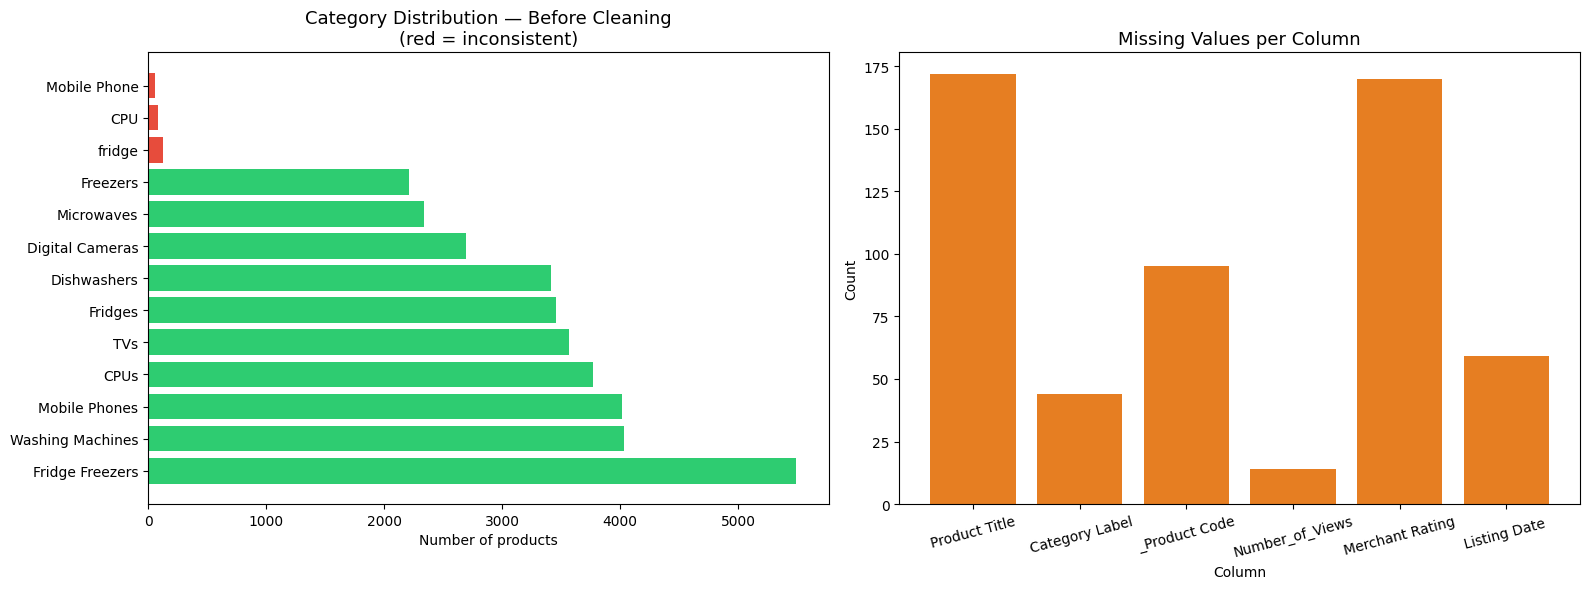


Dataset before cleaning: 35311 rows


In [127]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Category distribution (before cleaning)
category_counts = df[' Category Label'].value_counts()
colors = ['#e74c3c' if x in ['fridge', 'CPU', 'Mobile Phone'] 
          else '#2ecc71' for x in category_counts.index]

axes[0].barh(category_counts.index, category_counts.values, color=colors)
axes[0].set_title('Category Distribution — Before Cleaning\n(red = inconsistent)', fontsize=13)
axes[0].set_xlabel('Number of products')

# 2. Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
axes[1].bar(missing.index, missing.values, color='#e67e22')
axes[1].set_title('Missing Values per Column', fontsize=13)
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/exploration.png', bbox_inches='tight')
plt.show()

print(f"\nDataset before cleaning: {df.shape[0]} rows")

## 🧹 Step 3 — Clean & prepare

Based on the exploration findings, we need to:
- Strip whitespace from column names
- Remove rows with missing `Product Title` or `Category Label`
- Standardize inconsistent category labels
- Drop columns irrelevant to model training
- Verify the final dataset is clean and ready for modeling

In [128]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Remove rows with missing Product Title or Category Label
df = df.dropna(subset=['Product Title', 'Category Label'])

# Standardize inconsistent category labels
df['Category Label'] = df['Category Label'].replace({
    'fridge': 'Fridges',
    'CPU': 'CPUs',
    'Mobile Phone': 'Mobile Phones'
})

# Verify
print("--- Statistics after cleaning ---")
print(f"Total rows: {df.shape[0]}")
print()
print("Category distribution:")
print(df['Category Label'].value_counts())

--- Statistics after cleaning ---
Total rows: 35096

Category distribution:
Category Label
Fridge Freezers     5470
Mobile Phones       4057
Washing Machines    4015
CPUs                3831
Fridges             3559
TVs                 3541
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
Name: count, dtype: int64


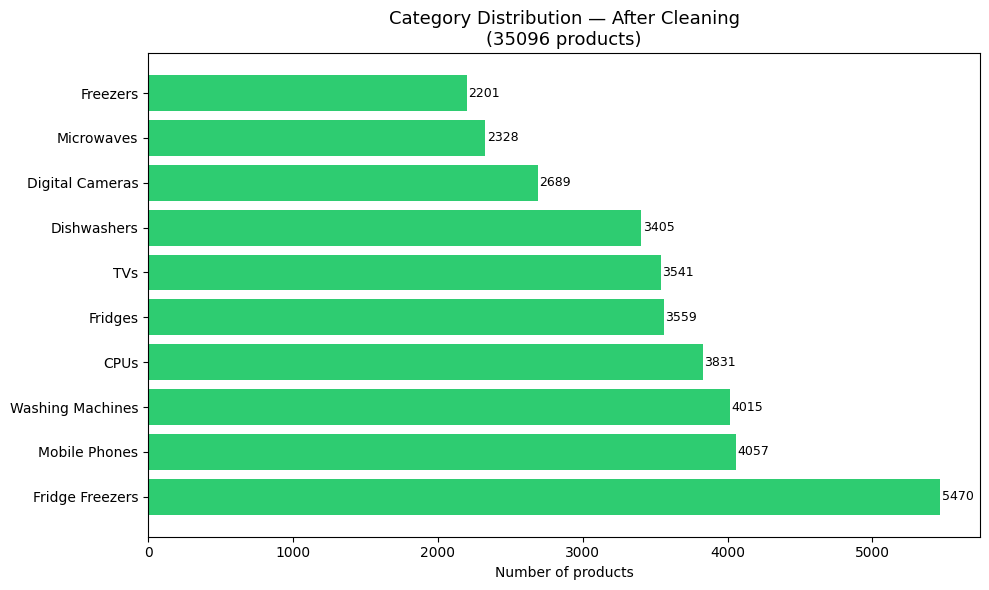

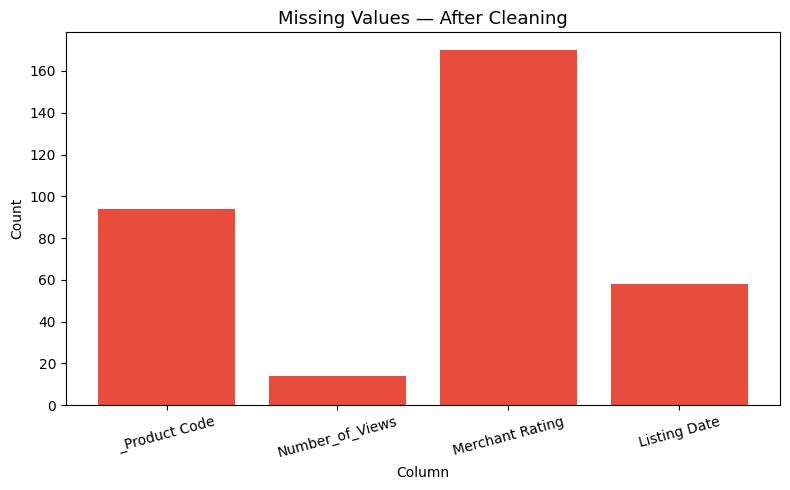

Missing values after cleaning:
product ID           0
Product Title        0
Merchant ID          0
Category Label       0
_Product Code       94
Number_of_Views     14
Merchant Rating    170
Listing Date        58
dtype: int64


In [129]:
fig, ax = plt.subplots(figsize=(10, 6))

category_counts = df['Category Label'].value_counts()

ax.barh(category_counts.index, category_counts.values, color='#2ecc71')
ax.set_title(f'Category Distribution — After Cleaning\n({df.shape[0]} products)', fontsize=13)
ax.set_xlabel('Number of products')

for i, v in enumerate(category_counts.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/exploration_clean.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))

missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]

if len(missing_after) == 0:
    print("✅ No missing values remaining!")
else:
    ax.bar(missing_after.index, missing_after.values, color='#e74c3c')
    ax.set_title('Missing Values — After Cleaning', fontsize=13)
    ax.set_xlabel('Column')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.savefig('../data/missing_after.png', bbox_inches='tight')
    plt.show()
    
    print("Missing values after cleaning:")
print(df.isnull().sum())

In [130]:
# Keep only relevant columns
df = df[['Product Title', 'Category Label']]

print("Remaining columns:", df.columns.tolist())
print(f"Shape: {df.shape}")
df.head()

Remaining columns: ['Product Title', 'Category Label']
Shape: (35096, 2)


,Product Title,Category Label
0,apple iphone 8 plus 64gb silver,Mobile Phones
1,apple iphone 8 plus 64 gb spacegrau,Mobile Phones
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,Mobile Phones
3,apple iphone 8 plus 64gb space grey,Mobile Phones
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,Mobile Phones


## 🔧 Step 4 — Feature engineering

The core input for our model is the `Product Title` text, which will be 
transformed using TF-IDF vectorization. 

To potentially improve model performance, we extract additional signals 
directly from the product title:

- **title_length** — total number of characters
- **word_count** — number of words in the title
- **has_numbers** — whether the title contains digits (e.g. 64gb, 55 inch)
- **has_brand** — whether the title contains a known brand name

> 💡 Note: TF-IDF already captures most of the textual information.
> These additional features may provide a small but meaningful boost.

In [131]:
# Title length
df['title_length'] = df['Product Title'].apply(len)

# Word count
df['word_count'] = df['Product Title'].apply(lambda x: len(x.split()))

# Wheather the title contains a number (64gb, 55 inch, 1400 spin...)
df['has_numbers'] = df['Product Title'].str.contains(r'\d', regex=True).astype(int)

# Whether the title contains a brand
brands = ['samsung', 'bosch', 'apple', 'neff', 'hotpoint', 
          'liebherr', 'sony', 'lg', 'canon', 'olympus']
df['has_brand'] = df['Product Title'].str.lower().apply(
    lambda x: int(any(brand in x for brand in brands))
)

print("--- Dataset check with new columns ---")
print(df[['Product Title', 'title_length', 'word_count', 'has_numbers', 'has_brand']].head())

print("\n--- Basic statistics for new columns ---")
print(df[['title_length', 'word_count']].describe())

print("\n---  Check how many products has 'brand' or 'number' in product title ---")
print(f"With number: {df['has_numbers'].sum()}")
print(f"With brand:   {df['has_brand'].sum()}")

--- Dataset check with new columns ---
                                       Product Title  title_length  \
0                    apple iphone 8 plus 64gb silver            31   
1                apple iphone 8 plus 64 gb spacegrau            35   
2  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...            70   
3                apple iphone 8 plus 64gb space grey            35   
4  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...            54   

   word_count  has_numbers  has_brand  
0           6            1          1  
1           7            1          1  
2          13            1          1  
3           7            1          1  
4          11            1          1  

--- Basic statistics for new columns ---
       title_length    word_count
count  35096.000000  35096.000000
mean      52.984813      8.666144
std       22.438958      4.164598
min        5.000000      1.000000
25%       39.000000      6.000000
50%       52.000000      8.000000
75%       65.000000 